In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import torch
import torch.nn as nn
import torch.optim as optim
import os
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt


# Load dataset
data = pd.read_csv("combined_data.csv", parse_dates=["date"])

# Feature Engineering
data["year"] = data["date"].dt.year
data["month"] = data["date"].dt.month
data["day"] = data["date"].dt.day

# Define Target Variables
threshold = np.percentile(data["r1h"].dropna(), 95)
data["extreme_rain"] = (data["r1h"] >= threshold).astype(int)  # Binary Classification Target

# Selecting Features
features = ["rfh_avg", "r1h_avg", "r3h_avg", "year", "month", "day"]
X = data[features]
y_regression = data["r1h"]  # For Regression
y_classification = data["extreme_rain"]  # For Classification

# Feature Scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Creating Sequences for LSTM
def create_sequences(data, target, seq_length=5):
    Xs, ys = [], []
    for i in range(len(data) - seq_length):
        Xs.append(data[i:i + seq_length])
        ys.append(target[i + seq_length])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y_regression.values)

#split it into 70(train), 15(validation), 15(testing).
X_train, X_temp, y_train, y_temp = train_test_split(X_seq, y_seq, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Convert to PyTorch tensors (ensuring float32 type)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# DataLoader for batch processing
batch_size = 32
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

# ---- PyTorch LSTM Model for Rainfall Prediction ---- #
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

# Model Initialization
input_size = X_train.shape[2]
hidden_size = 64  # Reduced from 128
num_layers = 2  # Reduced from 3
output_size = 1
model = LSTMModel(input_size, hidden_size, num_layers, output_size)
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0005)

# Training Loop
epochs = 100
for epoch in range(epochs):
    model.train()
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.float(), batch_y.float()  
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

# Evaluate Model
model.save('Rainfall_Model')



Epoch [10/100], Loss: 536.9045
Epoch [20/100], Loss: 326.8798
Epoch [30/100], Loss: 382.9496
Epoch [40/100], Loss: 218.3694
Epoch [50/100], Loss: 198.0540
Epoch [60/100], Loss: 596.8680
Epoch [70/100], Loss: 149.1534
Epoch [80/100], Loss: 1188.8807
Epoch [90/100], Loss: 706.6263
Epoch [100/100], Loss: 719.1039


AttributeError: 'LSTMModel' object has no attribute 'save'

In [4]:
torch.save(model.state_dict(), "Rainfall_Model.pth")

In [5]:
model.eval()
with torch.no_grad():
    y_pred_lstm = model(X_test_tensor.float()).detach().numpy()

# LSTM Model Evaluation
print("LSTM Model Performance:")
print("Mean Absolute Error:", np.mean(abs(y_pred_lstm.flatten() - y_test)))

LSTM Model Performance:
Mean Absolute Error: 13.542757031463324


In [6]:
# ---- Random Forest Model for Extreme Rain Classification ---- #
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train.reshape(X_train.shape[0], -1), y_classification.iloc[:len(X_train)])  # Use classification labels
y_pred_rf = rf_model.predict(X_test.reshape(X_test.shape[0], -1))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     39557
           1       0.04      0.01      0.02      1699

    accuracy                           0.95     41256
   macro avg       0.50      0.50      0.49     41256
weighted avg       0.92      0.95      0.93     41256

Accuracy Score: 0.9500193911188676


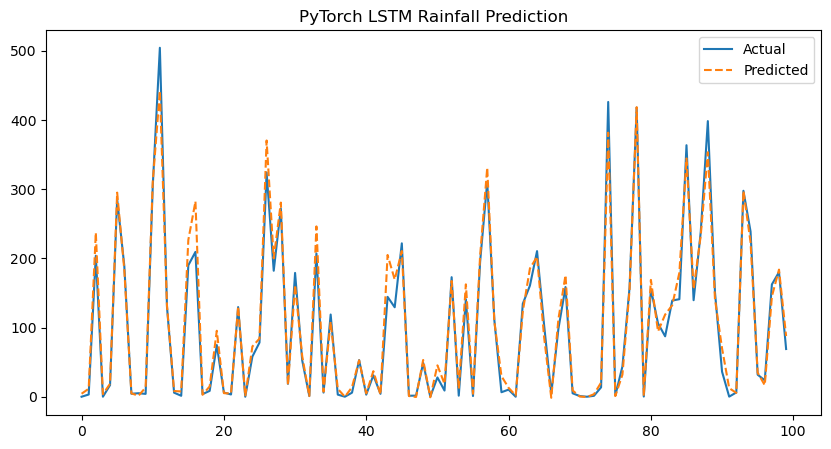

In [3]:
# Random Forest Evaluation
print("Random Forest Classification Report:")
print(classification_report(y_classification.iloc[:len(y_test)], y_pred_rf))
print("Accuracy Score:", accuracy_score(y_classification.iloc[:len(y_test)], y_pred_rf))


# Visualization
plt.figure(figsize=(10, 5))
plt.plot(y_test[:100], label='Actual')
plt.plot(y_pred_lstm.flatten()[:100], label='Predicted', linestyle='dashed')
plt.legend()
plt.title("PyTorch LSTM Rainfall Prediction")
plt.show()


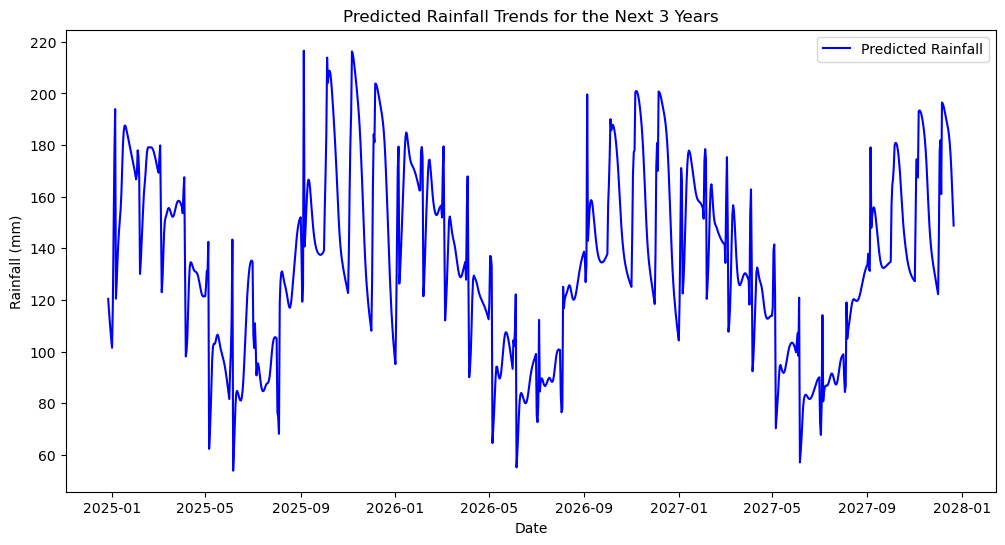

In [9]:
from datetime import timedelta


# Define future time range (3 years ahead)
last_date = data["date"].max()
future_dates = [last_date + timedelta(days=i) for i in range(1, 3 * 365 + 1)]

# Generate a DataFrame for future predictions
future_data = pd.DataFrame(future_dates, columns=["date"])
future_data["year"] = future_data["date"].dt.year
future_data["month"] = future_data["date"].dt.month
future_data["day"] = future_data["date"].dt.day

# Use moving averages for feature values
future_data["rfh_avg"] = data["rfh_avg"].rolling(window=30, min_periods=1).mean().iloc[-1]
future_data["r1h_avg"] = data["r1h_avg"].rolling(window=30, min_periods=1).mean().iloc[-1]
future_data["r3h_avg"] = data["r3h_avg"].rolling(window=30, min_periods=1).mean().iloc[-1]

# Selecting Features
features = ["rfh_avg", "r1h_avg", "r3h_avg", "year", "month", "day"]

# Scale features
future_scaled = scaler.transform(future_data[features])

# Sequence length used in the LSTM model
sequence_length = 5

# Convert into LSTM sequences
def create_sequences(data, seq_length):
    Xs = []
    for i in range(len(data) - seq_length):
        Xs.append(data[i:i + seq_length])
    return np.array(Xs)

X_future_seq = create_sequences(future_scaled, sequence_length)
X_future_tensor = torch.tensor(X_future_seq, dtype=torch.float32)

# Predict future rainfall using the trained LSTM model
model.eval()
with torch.no_grad():
    y_future_pred = model(X_future_tensor).detach().numpy()

# Classify extreme rainfall
future_classification = rf_model.predict(X_future_seq.reshape(X_future_seq.shape[0], -1))

# Trim the first 'sequence_length' rows from future_data to match prediction size
future_data = future_data.iloc[sequence_length:].reset_index(drop=True)

# Store predictions
future_data["predicted_rainfall"] = y_future_pred.flatten()
future_data["extreme_rain_pred"] = future_classification

# Plot trends
plt.figure(figsize=(12, 6))
plt.plot(future_data["date"], future_data["predicted_rainfall"], label="Predicted Rainfall", color='b')
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.title("Predicted Rainfall Trends for the Next 3 Years")
plt.legend()
plt.show()


In [10]:
future_data

,date,year,month,day,rfh_avg,r1h_avg,r3h_avg,predicted_rainfall,extreme_rain_pred
0,2024-12-27,2024,12,27,49.34018,148.72445,437.33018,120.472168,0
1,2024-12-28,2024,12,28,49.34018,148.72445,437.33018,116.012817,0
2,2024-12-29,2024,12,29,49.34018,148.72445,437.33018,111.846344,0
3,2024-12-30,2024,12,30,49.34018,148.72445,437.33018,108.026184,0
4,2024-12-31,2024,12,31,49.34018,148.72445,437.33018,104.580963,0
...,...,...,...,...,...,...,...,...,...
1085,2027-12-17,2027,12,17,49.34018,148.72445,437.33018,176.435684,0
1086,2027-12-18,2027,12,18,49.34018,148.72445,437.33018,170.770233,0
1087,2027-12-19,2027,12,19,49.34018,148.72445,437.33018,163.850555,0
1088,2027-12-20,2027,12,20,49.34018,148.72445,437.33018,156.220642,0
